The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


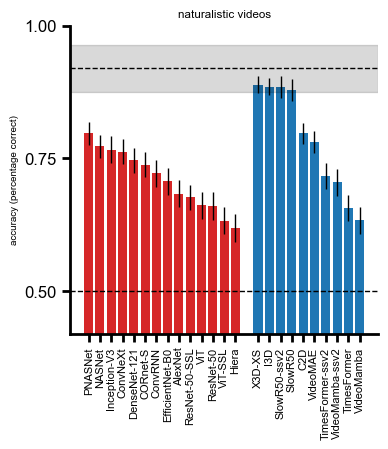

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


naturalistic videos
image ANNs mean accuracy: 0.71 ± 0.05
video ANNs mean accuracy: 0.78 ± 0.09
image ANNs - video ANNs mean difference: -0.07
image ANNs max accuracy: 0.80
video ANNs max accuracy: 0.89


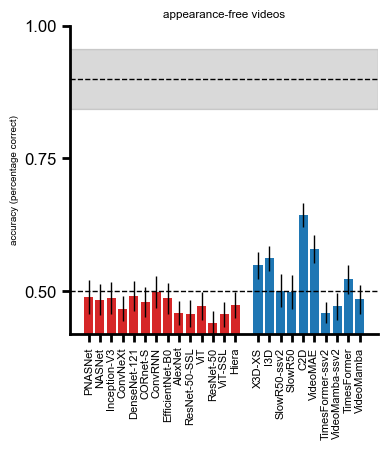

appearance-free videos
image ANNs mean accuracy: 0.47 ± 0.02
video ANNs mean accuracy: 0.53 ± 0.05
image ANNs - video ANNs mean difference: -0.05
image ANNs max accuracy: 0.50
video ANNs max accuracy: 0.64


In [5]:
import sys
sys.path.append('../')

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import cm
import scipy.stats as stats

from utils.plot_utils import journal_figure_pdf, journal_figure

import scienceplots

plt.style.use(['nature'])

# Define static (image-based) models with their properties: [type, color, label]
static_models = {
    "images_moving1_alexnet_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'AlexNet'], 
    "images_moving1_convnext_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
    "images_moving1_densenet121_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'DenseNet-121'], 
    "images_moving1_efficientnet_b0_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'EfficientNet-B0'], 
    "images_moving1_hiera_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'Hiera'], 
    "images_moving1_inception_v3_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'Inception-V3'], 
    "images_moving1_pnasnet_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'PNASNet'], 
    "images_moving1_resnet50_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ResNet-50'], 
    "images_moving1_resnet50_ssl_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ResNet-50-SSL'], 
    "images_moving1_vit_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ViT'], 
    "images_moving1_vit_ssl_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ViT-SSL'], 
    "images_moving1_nasnet_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'NASNet'], 
    "images_moving1_rgc_intermediate_features_ff_srp-rgb2afv_1000_10.h5" : ['ri', 'tab:red', 'ConvRNN'],
    "images_moving1_CORnet-S_IT_features_srp-rgb2afv_1000_10.h5" : ['ri', 'tab:red', 'CORnet-S'],
}

# Define dynamic (video-based) models with their properties: [type, color, label]
dynamic_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_features_srp-rgb2afv_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'],
}

# Path to folder containing model classification scores
scores_path = '../../scores/figure3'

# Combine static and dynamic models
models = {**static_models, **dynamic_models}

# Initialize lists to store results for RGB->AFV decoding task
values_rgb2afv_rgb = []
errors_rgb2afv_rgb = []
values_rgb2afv_afv = []
errors_rgb2afv_afv = []

vid_values_rgb2afv_rgb = []
vid_values_rgb2afv_afv = []

# Initialize lists to store results for AFV->RGB decoding task
values_afv2rgb_rgb = []
errors_afv2rgb_rgb = []
values_afv2rgb_afv = []
errors_afv2rgb_afv = []

vid_values_afv2rgb_rgb = []
vid_values_afv2rgb_afv = []

# ============================================================================
# PROCESS RGB->AFV DECODING RESULTS FOR EACH MODEL
# ============================================================================
methods_names = list(models.keys())
for name in methods_names:
    # Load RGB->AFV decoding results
    file_rgb_rgb2afv = h5py.File(f'{scores_path}/{name}/decode_obj_dir_linear_rgb2afv.h5', 'r')
    #print(list(file_rgb_rgb2afv.keys()))
    # Process i1 scores for original (RGB) features
    i1_per_time_rgb2afv_rgb = np.array(file_rgb_rgb2afv[f'i1_all_rgb'])
    #print(name, np.nanmean(i1_per_time_rgb2afv_rgb))
    i1_per_time_rgb2afv_rgb = np.nanmean(i1_per_time_rgb2afv_rgb, axis=-1)
    i1_per_time_rgb2afv_rgb = np.nanmean(i1_per_time_rgb2afv_rgb, axis=0)
    
    # Find best performing video and extract its scores
    i1_per_time_rgb2afv_rgb_m = np.nanmean(i1_per_time_rgb2afv_rgb, axis=-1)
    max_id = np.nanargmax(i1_per_time_rgb2afv_rgb_m)
    i1_per_time_rgb2afv_rgb = i1_per_time_rgb2afv_rgb[max_id]

    # Process i1 scores for AFV features
    i1_per_time_rgb2afv_afv = np.array(file_rgb_rgb2afv[f'i1_all_afv'])
    i1_per_time_rgb2afv_afv = np.nanmean(i1_per_time_rgb2afv_afv, axis=-1)
    i1_per_time_rgb2afv_afv = np.nanmean(i1_per_time_rgb2afv_afv, axis=0)

    # Find best performing video and extract its scores
    i1_per_time_rgb2afv_afv_m = np.nanmean(i1_per_time_rgb2afv_afv, axis=-1)
    #max_id = np.nanargmax(i1_per_time_rgb2afv_afv_m)
    i1_per_time_rgb2afv_afv = i1_per_time_rgb2afv_afv[max_id]
    
    # Calculate mean and standard error for RGB->AFV task (original features)
    i1_per_time_rgb2afv_rgb_mean = np.nanmean(i1_per_time_rgb2afv_rgb, axis=0)
    i1_per_time_rgb2afv_rgb_se = np.nanstd(i1_per_time_rgb2afv_rgb, axis=0) / np.sqrt(i1_per_time_rgb2afv_rgb.shape[0])

    values_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb_mean)
    errors_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb_se)

    # Calculate mean and standard error for RGB->AFV task (AFV features)
    i1_per_time_rgb2afv_afv_mean = np.nanmean(i1_per_time_rgb2afv_afv, axis=0)
    i1_per_time_rgb2afv_afv_se = np.nanstd(i1_per_time_rgb2afv_afv, axis=0) / np.sqrt(i1_per_time_rgb2afv_afv.shape[0])

    values_rgb2afv_afv.append(i1_per_time_rgb2afv_afv_mean)
    errors_rgb2afv_afv.append(i1_per_time_rgb2afv_afv_se)

    vid_values_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb)  
    vid_values_rgb2afv_afv.append(i1_per_time_rgb2afv_afv)

# Human accuracy benchmarks
human_accouracy_mean = [0.92, 0.9]
human_accouracy_std = [0.044, 0.056]

# ============================================================================
# PLOT RGB->AFV DECODING: Per-model bar plots
# ============================================================================
for p, phase in enumerate(['rgb', 'afv']):
    plt.figure(figsize=(4, 4))

    # Sort models by performance on original features
    if phase == 'rgb':
        sorted_indices_rgb2afv = np.argsort(values_rgb2afv_rgb)[::-1]
        sorted_values = [values_rgb2afv_rgb[i] for i in sorted_indices_rgb2afv]
        sorted_errors = [errors_rgb2afv_rgb[i] for i in sorted_indices_rgb2afv]
    else:
        sorted_values = [values_rgb2afv_afv[i] for i in sorted_indices_rgb2afv]
        sorted_errors = [errors_rgb2afv_afv[i] for i in sorted_indices_rgb2afv]

    # Get labels for sorted models
    sorted_names = [methods_names[i] for i in sorted_indices_rgb2afv]
    sorted_labels = [models[name][2] for name in sorted_names]

    # Separate models into video (dynamic) and image (static) groups
    video_indices = [i for i, name in enumerate(sorted_names) if models[name][0] in ['d', 'rv']]
    image_indices = [i for i, name in enumerate(sorted_names) if models[name][0] in ['f', 'ri']]
    
    # Prepare bar plot data
    x_positions = []
    x_labels = []
    x_colors = []
    x_values = []
    x_errors = []
    
    pos = 0
    
    # Add image models (red bars)
    for i in image_indices:
        x_positions.append(pos)
        x_labels.append(sorted_labels[i])
        x_colors.append('tab:red')
        x_values.append(sorted_values[i])
        x_errors.append(sorted_errors[i])
        pos += 1

    pos += 1  # Gap between video and image models

    # Add video models (blue bars)
    for i in video_indices:
        x_positions.append(pos)
        x_labels.append(sorted_labels[i])
        x_colors.append('tab:blue')
        x_values.append(sorted_values[i])
        x_errors.append(sorted_errors[i])
        pos += 1
    
    
    
    # Create bar plot
    plt.bar(x_positions, x_values, yerr=x_errors, color=x_colors, width=0.8)
    plt.xticks(x_positions, x_labels)
 
    # Add reference lines
    plt.axhline(0.5, color='black', linestyle='--', linewidth=1)
    plt.axhline(human_accouracy_mean[p], color='black', linestyle='--', linewidth=1)
    plt.axhspan(human_accouracy_mean[p] - human_accouracy_std[p], human_accouracy_mean[p] + human_accouracy_std[p], color='black', alpha=0.15)

    plt.ylabel("accuracy (percentage correct)")
    plt.xticks(rotation=90)
    plt.ylim(0.42, 1)
    plt.yticks(np.arange(0.5, 1.01, 0.25))
    plt.title(f"{'naturalistic videos' if phase == 'rgb' else 'appearance-free videos'}")

    journal_figure(do_save=True, filename=f'../../plots/figure3_decode_obj_dir_linear_rgb2afv-{phase}_barplot_grouped.eps', fontsize_x=8)
    journal_figure_pdf(do_save=True, filename=f'../../plots/figure3_decode_obj_dir_linear_rgb2afv-{phase}_barplot_grouped.pdf', fontsize_x=8)
    plt.show()

    values_ff = [sorted_values[j] for j in image_indices]
    values_dd = [sorted_values[j] for j in video_indices]
    print(f"{'naturalistic videos' if phase == 'rgb' else 'appearance-free videos'}")
    print(f'image ANNs mean accuracy: {np.nanmean(values_ff):.2f} ± {np.nanstd(values_ff):.2f}')
    print(f'video ANNs mean accuracy: {np.nanmean(values_dd):.2f} ± {np.nanstd(values_dd):.2f}')
    print(f'image ANNs - video ANNs mean difference: {np.nanmean(values_ff) - np.nanmean(values_dd):.2f}')
    print(f'image ANNs max accuracy: {np.nanmax(values_ff):.2f}')
    print(f'video ANNs max accuracy: {np.nanmax(values_dd):.2f}')